In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Titanic_dataset_kaggle.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [4]:
df.isnull().mean()*100

Survived     0.000000
Age         20.574163
Fare         0.239234
dtype: float64

In [5]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [8]:
x_train

,Age,Fare
280,23.0,8.6625
284,2.0,20.2125
40,39.0,13.4167
17,21.0,7.2250
362,31.0,21.0000
...,...,...
299,29.0,7.8542
22,NaN,31.6833
72,29.0,7.9250
15,24.0,27.7208


In [9]:
x_train['Age_imputed']=x_train['Age']
x_test['Age_imputed']=x_test['Age']

In [11]:
x_train.tail()

,Age,Fare,Age_imputed
299,29.0,7.8542,29.0
22,NaN,31.6833,NaN
72,29.0,7.9250,29.0
15,24.0,27.7208,24.0
168,NaN,27.7208,NaN


In [15]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_train['Age_imputed'].isnull().sum(), random_state=42)
    .values
)

x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_test['Age_imputed'].isnull().sum(), random_state=42)
    .values
)

In [16]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([24.  , 27.  , 21.  , 41.  , 26.  , 67.  , 24.  , 23.  , 46.  ,
       21.  , 18.  , 48.  , 50.  , 25.  , 50.  , 20.  , 36.5 , 57.  ,
       26.  , 25.  ,  0.33, 29.  , 18.  , 20.  , 29.  , 19.  , 50.  ,
       18.  , 33.  , 30.  , 27.  , 21.  , 27.  , 21.  , 32.5 , 35.  ,
       29.  , 24.  , 18.  , 43.  , 18.  , 28.  , 18.  , 45.  , 47.  ,
       21.  ,  1.  , 41.  , 30.  , 49.  , 25.  , 21.  ,  8.  ,  8.  ,
       60.  , 26.  , 14.5 , 29.  , 39.  , 60.  , 18.5 , 30.  , 32.  ,
       26.  , 12.  , 33.  , 21.  , 40.  , 45.  , 42.  , 22.  , 57.  ])

In [17]:
x_train['Age'].isnull().sum()

72

In [18]:
x_train

,Age,Fare,Age_imputed
280,23.0,8.6625,23.0
284,2.0,20.2125,2.0
40,39.0,13.4167,39.0
17,21.0,7.2250,21.0
362,31.0,21.0000,31.0
...,...,...,...
299,29.0,7.8542,29.0
22,NaN,31.6833,22.0
72,29.0,7.9250,29.0
15,24.0,27.7208,24.0


<Axes: xlabel='Age_imputed', ylabel='Density'>

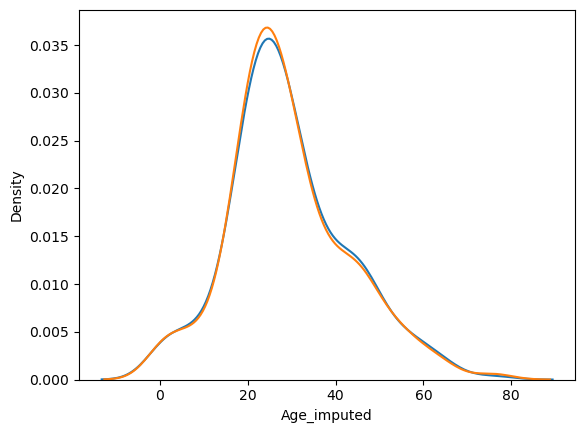

In [22]:
sns.distplot(x_train['Age'],label='Original',hist=False)
sns.distplot(x_train['Age_imputed'],label = 'Imputed',hist=False)


In [24]:
print('Original variable variance:', x_train['Age'].var())
print('Variance after random imputation:',x_train['Age_imputed'].var())

Original variable variance: 184.7040299669505
Variance after random imputation: 185.74244498030956


In [26]:
x_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2333.007047,216.034928,171.959600
Age,216.034928,184.704030,184.704030
Age_imputed,171.959600,184.704030,185.742445


<Axes: >

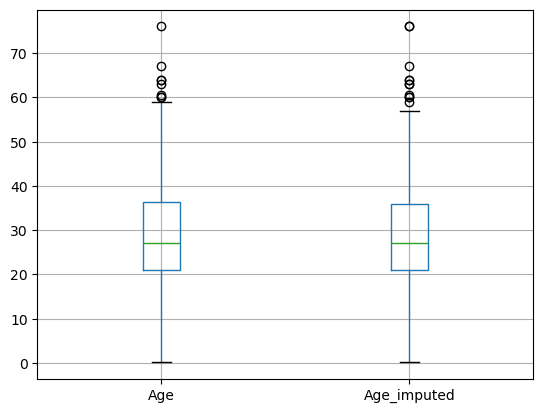

In [27]:
x_train[['Age','Age_imputed']].boxplot()

In [34]:
def impute_age(row):
    if pd.isnull(row.Age):
        return x_train.Age.dropna().sample(
            1,
            random_state=int(row.Fare) if pd.notna(row.Fare) else 0
        ).iloc[0]
    return row.Age

In [35]:
data=pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])


In [36]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [37]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [38]:
x=data
y=data['SalePrice']

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [42]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [44]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1287,NaN,TA,190000,TA,NaN
63,NaN,TA,140000,TA,NaN
838,NaN,TA,144000,TA,NaN
149,NaN,Fa,115000,Fa,NaN
53,Gd,TA,385000,TA,Gd


In [46]:

x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

In [48]:
temp = pd.concat(
        [
            x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
            x_train['GarageQual_imputed'].value_counts() / len(x_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [49]:
temp

,original,imputed
TA,0.951043,0.946918
Fa,0.037171,0.041952
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [51]:
temp = pd.concat(
        [
            x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
            x_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,1.377990
TA,0.412439,1.155502
Fa,0.040917,0.114833
Po,0.027823,0.078947
Ex,0.024550,0.066986


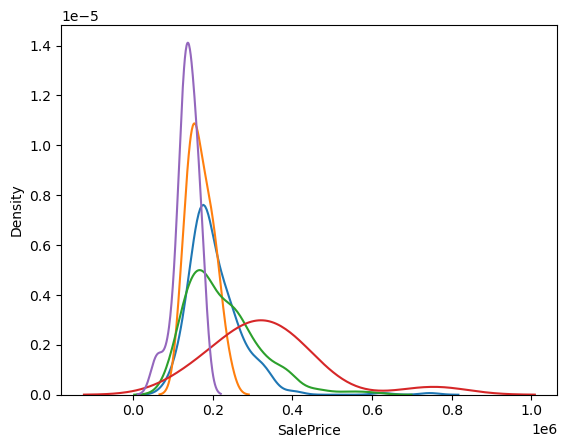

In [54]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

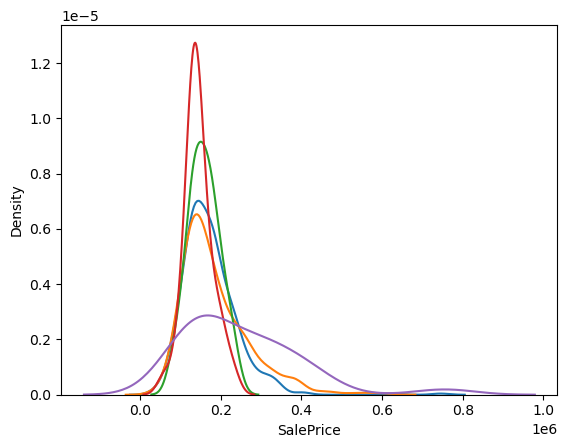

In [56]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()